In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import librosa
import glob
import json
import pickle
import shutil

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.utils import register_keras_serializable

tf.get_logger().setLevel('ERROR')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

np.random.seed(42)
tf.random.set_seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU Available: {gpus[0].name}")
else:
    print("No GPU detected - using CPU")

print("Completed setup")

GPU Available: /physical_device:GPU:0
Completed setup


In [ ]:
import kagglehub
path = kagglehub.dataset_download("yashdogra/speech-commands")
print(f"Path to dataset files: {path}")

Using Colab cache for faster access to the 'speech-commands' dataset.
Path to dataset files: /kaggle/input/speech-commands


In [ ]:
if os.path.exists(path):
    contents = os.listdir(path)
    print(f"Dataset found at: {path}")
    print(f"Total folders: {len(contents)}")
    print(f"Sample folders: {contents[:5]}...")
else:
    print(f"Dataset NOT found at: {path}")

COMMANDS = [
    'yes', 'no', 'up', 'down', 'left', 'right',
    'on', 'off', 'stop', 'go'
]

SAMPLE_RATE    = 16000
AUDIO_LENGTH   = 16000
N_MELS         = 128
N_FFT          = 2048
HOP_LENGTH     = 160
MAX_SAMPLES    = None

NOISE_AUGMENT_PROB = 0.4
NOISE_SNR_DB       = 10

MAX_OUTPUT_LEN  = 2
N_SEQ_TRAIN     = 8000
N_SEQ_VAL       = 1500
N_SEQ_TEST      = 1500
SEQ_SILENCE_MS  = 200
MODEL_NAME      = 'resnet_sequencing'

print(f"Commands: {COMMANDS}")
print(f"Expected spectrogram shape: ({N_MELS}, {AUDIO_LENGTH // HOP_LENGTH + 1})")
print(f"Model name: {MODEL_NAME}")

Dataset found at: /kaggle/input/speech-commands
Total folders: 40
Sample folders: ['no', 'two', 'backward', 'four', 'five']...
Commands: ['yes', 'no', 'up', 'down', 'left', 'right', 'on', 'off', 'stop', 'go']
Expected spectrogram shape: (128, 101)
Model name: resnet_sequencing


# Preprocessing Pipeline

In [ ]:
def load_audio(file_path, target_sr=SAMPLE_RATE):
    audio, sr = librosa.load(file_path, sr=target_sr)
    return audio, sr

def pad_or_trim(audio, target_length=AUDIO_LENGTH):
    if len(audio) < target_length:
        audio = np.pad(audio, (0, target_length - len(audio)), mode='constant')
    else:
        audio = audio[:target_length]
    return audio

def normalize_audio(audio):
    max_val = np.max(np.abs(audio))
    if max_val > 0:
        audio = audio / max_val
    return audio

def preprocess_audio(file_path, target_sr=SAMPLE_RATE, target_length=AUDIO_LENGTH):
    audio, sr = load_audio(file_path, target_sr)
    audio = pad_or_trim(audio, target_length)
    audio = normalize_audio(audio)
    return audio

def extract_mel_spectrogram(audio, sr=SAMPLE_RATE, n_mels=N_MELS,
                             n_fft=N_FFT, hop_length=HOP_LENGTH):
    mel_spec = librosa.feature.melspectrogram(
        y=audio, sr=sr, n_mels=n_mels, n_fft=n_fft, hop_length=hop_length
    )
    return librosa.power_to_db(mel_spec, ref=np.max)

NOISE_PATH = os.path.join(path, '_background_noise_')

def load_noise_files(noise_path, target_sr=SAMPLE_RATE):
    noise_clips = []
    for f in glob.glob(os.path.join(noise_path, '*.wav')):
        audio, _ = librosa.load(f, sr=target_sr)
        noise_clips.append(audio)
    print(f"Loaded {len(noise_clips)} noise files")
    return noise_clips

def create_noise_samples(noise_clips, target_length=AUDIO_LENGTH, n_samples=1500):
    samples = []
    for _ in range(n_samples):
        clip  = noise_clips[np.random.randint(len(noise_clips))]
        if len(clip) < target_length:
            clip = np.pad(clip, (0, target_length - len(clip)))
        start = np.random.randint(0, len(clip) - target_length)
        samples.append(clip[start:start + target_length])
    return samples

def mix_noise(audio, noise_clips, snr_db=NOISE_SNR_DB):
    noise = noise_clips[np.random.randint(len(noise_clips))]
    if len(noise) < len(audio):
        noise = np.pad(noise, (0, len(audio) - len(noise)))
    start = np.random.randint(0, len(noise) - len(audio) + 1)
    noise = noise[start:start + len(audio)]
    signal_power = np.mean(audio ** 2) + 1e-9
    noise_power  = np.mean(noise  ** 2) + 1e-9
    scale = np.sqrt(signal_power / (noise_power * (10 ** (snr_db / 10))))
    return normalize_audio(audio + scale * noise)

noise_clips   = load_noise_files(NOISE_PATH)
noise_samples = create_noise_samples(noise_clips, n_samples=1500)
print(f"Created {len(noise_samples)} noise samples")
print(f"Expected spectrogram shape: ({N_MELS}, {AUDIO_LENGTH // HOP_LENGTH + 1})")

Loaded 6 noise files
Created 1500 noise samples
Expected spectrogram shape: (128, 101)


In [ ]:
class SpecAugment:
    def __init__(self, freq_mask_param=15, time_mask_param=10,
                 num_freq_masks=1, num_time_masks=1):
        self.freq_mask_param = freq_mask_param
        self.time_mask_param = time_mask_param
        self.num_freq_masks  = num_freq_masks
        self.num_time_masks  = num_time_masks

    def frequency_mask(self, spec):
        num_mels = spec.shape[0]
        for _ in range(self.num_freq_masks):
            f  = min(np.random.randint(0, self.freq_mask_param + 1), num_mels)
            f0 = np.random.randint(0, max(1, num_mels - f))
            spec[f0:f0 + f, :] = spec.mean()
        return spec

    def time_mask(self, spec):
        num_frames = spec.shape[1]
        for _ in range(self.num_time_masks):
            t  = min(np.random.randint(0, self.time_mask_param + 1), num_frames)
            t0 = np.random.randint(0, max(1, num_frames - t))
            spec[:, t0:t0 + t] = spec.mean()
        return spec

    def __call__(self, spec, augment_prob=0.5):
        if np.random.random() > augment_prob:
            return spec
        spec = spec.copy()
        spec = self.frequency_mask(spec)
        spec = self.time_mask(spec)
        return spec

spec_augment = SpecAugment(
    freq_mask_param=15, time_mask_param=10,
    num_freq_masks=1,   num_time_masks=1
)
print(f"Frequency mask: up to {spec_augment.freq_mask_param} bands")
print(f"Time mask: up to {spec_augment.time_mask_param} frames")

Frequency mask: up to 15 bands
Time mask: up to 10 frames


In [ ]:
def create_dataset(dataset_path, commands, noise_samples=None,
                   max_samples_per_class=None, verbose=True):
    X_raw, X, y = [], [], []
    print("LOADING DATASET")

    for command in commands:
        command_path = os.path.join(dataset_path, command)
        if not os.path.exists(command_path):
            print(f"Warning: Folder not found for '{command}'")
            continue
        files = [f for f in os.listdir(command_path) if f.endswith('.wav')]
        if max_samples_per_class:
            files = files[:max_samples_per_class]
        if verbose:
            print(f"  Processing '{command}': {len(files)} files")
        for file_name in files:
            try:
                audio    = preprocess_audio(os.path.join(command_path, file_name))
                features = extract_mel_spectrogram(audio)
                X_raw.append(audio)
                X.append(features)
                y.append(command)
            except Exception:
                continue

    if noise_samples is not None:
        print(f"  Processing '_background_noise_': {len(noise_samples)} samples")
        for audio in noise_samples:
            audio    = normalize_audio(audio)
            features = extract_mel_spectrogram(audio)
            X_raw.append(audio)
            X.append(features)
            y.append('_background_noise_')

    X_raw = np.array(X_raw)
    X     = np.array(X)
    y     = np.array(y)

    print(f"Dataset created: {len(X)} samples, {len(np.unique(y))} classes")
    print(f"Feature shape: {X.shape}")
    return X_raw, X, y

X_raw, X, y = create_dataset(
    path, COMMANDS,
    noise_samples=noise_samples,
    max_samples_per_class=MAX_SAMPLES
)

LOADING DATASET
  Processing 'yes': 4044 files
  Processing 'no': 3941 files
  Processing 'up': 3723 files
  Processing 'down': 3917 files
  Processing 'left': 3801 files
  Processing 'right': 3778 files
  Processing 'on': 3845 files
  Processing 'off': 3745 files
  Processing 'stop': 3872 files
  Processing 'go': 3880 files
  Processing '_background_noise_': 1500 samples
Dataset created: 40046 samples, 11 classes
Feature shape: (40046, 128, 101)


In [ ]:
print("PREPARING DATA")

label_encoder = LabelEncoder()
y_encoded     = label_encoder.fit_transform(y)
num_classes   = len(label_encoder.classes_)

print(f"Label encoding:")
for i, label in enumerate(label_encoder.classes_):
    print(f"  {i}: '{label}'")

X_train, X_test, X_raw_train, X_raw_test, y_train, y_test = train_test_split(
    X, X_raw, y_encoded, test_size=0.15, random_state=42, stratify=y_encoded)
X_train, X_val, X_raw_train, X_raw_val, y_train, y_val = train_test_split(
    X_train, X_raw_train, y_train, test_size=0.12, random_state=42, stratify=y_train)

print(f"\nDataset split:")
print(f"  Training:   {X_train.shape[0]:,} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation: {X_val.shape[0]:,} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test:       {X_test.shape[0]:,} ({X_test.shape[0]/len(X)*100:.1f}%)")

X_train = X_train[..., np.newaxis]
X_val   = X_val[..., np.newaxis]
X_test  = X_test[..., np.newaxis]

X_mean = float(np.mean(X_train))
X_std  = float(np.std(X_train))
X_train = (X_train - X_mean) / X_std
X_val   = (X_val   - X_mean) / X_std
X_test  = (X_test  - X_mean) / X_std

print(f"Input shape: {X_train.shape[1:]}")
print(f"Normalization: mean={X_mean:.4f}, std={X_std:.4f}")

PREPARING DATA
Label encoding:
  0: '_background_noise_'
  1: 'down'
  2: 'go'
  3: 'left'
  4: 'no'
  5: 'off'
  6: 'on'
  7: 'right'
  8: 'stop'
  9: 'up'
  10: 'yes'

Dataset split:
  Training:   29,954 (74.8%)
  Validation: 4,085 (10.2%)
  Test:       6,007 (15.0%)
Input shape: (128, 101, 1)
Normalization: mean=-56.7310, std=20.2851


In [ ]:
def create_sequential_dataset(X_raw, y, n_samples, max_commands=2,
                               silence_ms=SEQ_SILENCE_MS, sr=SAMPLE_RATE):
    silence = np.zeros(int(sr * silence_ms / 1000))
    X_seq, y_seq = [], []
    for _ in range(n_samples):
        indices = np.random.randint(0, len(X_raw), size=max_commands)
        parts, labels = [], []
        for idx in indices:
            parts.append(X_raw[idx])
            parts.append(silence)
            labels.append(y[idx])
        combined = normalize_audio(np.concatenate(parts))
        X_seq.append(combined)
        y_seq.append(labels)
    return X_seq, np.array(y_seq)

print("Creating sequential datasets...")
X_seq_train, y_seq_train = create_sequential_dataset(X_raw_train, y_train, N_SEQ_TRAIN)
X_seq_val,   y_seq_val   = create_sequential_dataset(X_raw_val,   y_val,   N_SEQ_VAL)
X_seq_test,  y_seq_test  = create_sequential_dataset(X_raw_test,  y_test,  N_SEQ_TEST)

sample_specs = np.array([extract_mel_spectrogram(X_seq_train[i])
                          for i in range(min(500, len(X_seq_train)))])
X_seq_mean = float(np.mean(sample_specs))
X_seq_std  = float(np.std(sample_specs))

print(f"  Train: {len(X_seq_train)}  Val: {len(X_seq_val)}  Test: {len(X_seq_test)}")
print(f"  Seq normalization: mean={X_seq_mean:.4f}, std={X_seq_std:.4f}")
print(f"  Sequence length: ~{len(X_seq_train[0])/SAMPLE_RATE:.1f}s")

Creating sequential datasets...
  Train: 8000  Val: 1500  Test: 1500
  Seq normalization: mean=-61.6768, std=19.5480
  Sequence length: ~2.4s


In [ ]:
@register_keras_serializable(package="CustomSchedules")
class CosineDecayWithWarmup(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_learning_rate=1e-3, decay_steps=10000,
                 warmup_steps=1000, min_learning_rate=1e-6):
        super().__init__()
        self.initial_learning_rate = initial_learning_rate
        self.decay_steps           = decay_steps
        self.warmup_steps          = warmup_steps
        self.min_learning_rate     = min_learning_rate

    def __call__(self, step):
        step     = tf.cast(step, tf.float32)
        warmup_f = tf.cast(self.warmup_steps, tf.float32)
        decay_f  = tf.cast(self.decay_steps,  tf.float32)
        warmup_lr   = self.initial_learning_rate * (step / tf.maximum(warmup_f, 1.0))
        decay_step  = step - warmup_f
        total_decay = tf.maximum(decay_f - warmup_f, 1.0)
        cosine      = 0.5 * (1.0 + tf.cos(np.pi * decay_step / total_decay))
        decayed_lr  = self.min_learning_rate + \
                      (self.initial_learning_rate - self.min_learning_rate) * cosine
        return tf.where(step < warmup_f, warmup_lr, decayed_lr)

    def get_config(self):
        return {
            'initial_learning_rate': float(self.initial_learning_rate),
            'decay_steps':           int(self.decay_steps),
            'warmup_steps':          int(self.warmup_steps),
            'min_learning_rate':     float(self.min_learning_rate)
        }

    @classmethod
    def from_config(cls, config):
        return cls(**config)

print("CosineDecayWithWarmup defined")

CosineDecayWithWarmup defined


In [ ]:
# ── Part 1: Precompute all spectrograms once ──────────────────
print("Precomputing single-command spectrograms...")
X_spec_train = np.array([extract_mel_spectrogram(a) for a in X_raw_train])
X_spec_train = (X_spec_train - X_mean) / X_std

X_spec_val = np.array([extract_mel_spectrogram(a) for a in X_raw_val])
X_spec_val = (X_spec_val - X_mean) / X_std

print("Precomputing sequential spectrograms...")
X_seq_spec_train = np.array([extract_mel_spectrogram(a) for a in X_seq_train])
X_seq_spec_train = (X_seq_spec_train - X_seq_mean) / X_seq_std

X_seq_spec_val = np.array([extract_mel_spectrogram(a) for a in X_seq_val])
X_seq_spec_val = (X_seq_spec_val - X_seq_mean) / X_seq_std

print(f"  Single train: {X_spec_train.shape}")
print(f"  Single val:   {X_spec_val.shape}")
print(f"  Seq train:    {X_seq_spec_train.shape}")
print(f"  Seq val:      {X_seq_spec_val.shape}")

# ── Part 2: Generator class ───────────────────────────────────
class CombinedCommandGenerator(keras.utils.Sequence):
    def __init__(self, X_spec_single, y_single, X_spec_seq, y_seq,
                 batch_size=32, shuffle=True, augment=True,
                 spec_augment=None, noise_clips=None,
                 X_raw_single=None, X_raw_seq=None,
                 single_mean=0, single_std=1,
                 seq_mean=0,    seq_std=1,
                 noise_prob=0.4, augment_prob=0.5, single_ratio=0.5):
        self.X_spec_single = X_spec_single
        self.y_single      = y_single
        self.X_spec_seq    = X_spec_seq
        self.y_seq         = y_seq
        self.X_raw_single  = X_raw_single
        self.X_raw_seq     = X_raw_seq
        self.batch_size    = batch_size
        self.shuffle       = shuffle
        self.augment       = augment
        self.spec_augment  = spec_augment or SpecAugment()
        self.noise_clips   = noise_clips
        self.noise_prob    = noise_prob
        self.single_mean   = single_mean
        self.single_std    = single_std
        self.seq_mean      = seq_mean
        self.seq_std       = seq_std
        self.augment_prob  = augment_prob
        self.n_single      = max(1, int(batch_size * single_ratio))
        self.n_seq         = batch_size - self.n_single
        self.single_idx    = np.arange(len(X_spec_single))
        self.seq_idx       = np.arange(len(X_spec_seq))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.X_spec_seq) / self.n_seq))

    def _augment_spec(self, spec):
        if self.augment:
            spec = self.spec_augment(spec.copy(), augment_prob=self.augment_prob)
        return spec

    def _maybe_add_noise(self, spec, raw_audio, mean, std):
        if (self.augment and self.noise_clips is not None
                and raw_audio is not None
                and np.random.random() < self.noise_prob):
            noisy = mix_noise(raw_audio, self.noise_clips)
            spec  = extract_mel_spectrogram(noisy)
            spec  = (spec - mean) / std
        return self._augment_spec(spec)

    def __getitem__(self, idx):
        s_idx   = self.single_idx[
            np.random.randint(0, len(self.single_idx), self.n_single)
        ]
        q_start = idx * self.n_seq
        q_end   = min(q_start + self.n_seq, len(self.X_spec_seq))
        q_idx   = self.seq_idx[q_start:q_end]

        single_specs = []
        for i in s_idx:
            raw  = self.X_raw_single[i] if self.X_raw_single is not None else None
            spec = self._maybe_add_noise(
                self.X_spec_single[i], raw, self.single_mean, self.single_std)
            single_specs.append(spec)

        seq_specs = []
        for i in q_idx:
            raw  = self.X_raw_seq[i] if self.X_raw_seq is not None else None
            spec = self._maybe_add_noise(
                self.X_spec_seq[i], raw, self.seq_mean, self.seq_std)
            seq_specs.append(spec)

        all_specs = single_specs + seq_specs
        max_T     = max(s.shape[1] for s in all_specs)
        padded    = np.array([
            np.pad(s, ((0, 0), (0, max_T - s.shape[1]))) for s in all_specs
        ])[..., np.newaxis]

        bsz          = len(s_idx) + len(q_idx)
        y_single_out = np.full(bsz, -1, dtype=np.int32)
        y_cmd1       = np.full(bsz, -1, dtype=np.int32)
        y_cmd2       = np.full(bsz, -1, dtype=np.int32)

        for i, si in enumerate(s_idx):
            y_single_out[i] = self.y_single[si]
        for i, qi in enumerate(q_idx):
            y_cmd1[len(s_idx) + i] = self.y_seq[qi, 0]
            y_cmd2[len(s_idx) + i] = self.y_seq[qi, 1]

        return padded, {'single_command': y_single_out,
                        'command_1':      y_cmd1,
                        'command_2':      y_cmd2}

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.single_idx)
            np.random.shuffle(self.seq_idx)


# ── Part 3: Instantiate generators ───────────────────────────
train_generator = CombinedCommandGenerator(
    X_spec_train, y_train, X_seq_spec_train, y_seq_train,
    batch_size=32, shuffle=True, augment=True,
    spec_augment=spec_augment,
    noise_clips=noise_clips,
    X_raw_single=X_raw_train,
    X_raw_seq=X_seq_train,
    single_mean=X_mean,  single_std=X_std,
    seq_mean=X_seq_mean, seq_std=X_seq_std,
    noise_prob=NOISE_AUGMENT_PROB,
    augment_prob=0.5, single_ratio=0.5
)

val_generator = CombinedCommandGenerator(
    X_spec_val, y_val, X_seq_spec_val, y_seq_val,
    batch_size=32, shuffle=False, augment=False,
    single_mean=X_mean,  single_std=X_std,
    seq_mean=X_seq_mean, seq_std=X_seq_std,
)

print(f"✓ Generators ready")
print(f"  Training batches:   {len(train_generator)}")
print(f"  Validation batches: {len(val_generator)}")

Precomputing single-command spectrograms...
Precomputing sequential spectrograms...
  Single train: (29954, 128, 101)
  Single val:   (4085, 128, 101)
  Seq train:    (8000, 128, 241)
  Seq val:      (1500, 128, 241)
✓ Generators ready
  Training batches:   500
  Validation batches: 94


In [ ]:
def residual_block(x, filters, kernel_size=3, stride=1, use_projection=False):
    shortcut = x
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, kernel_size, strides=1, padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    if use_projection or stride != 1:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same',
                                 kernel_initializer='he_normal',
                                 kernel_regularizer=keras.regularizers.l2(1e-4))(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Add()([x, shortcut])
    return layers.ReLU()(x)

def squeeze_excitation_block(x, ratio=16):
    channels = x.shape[-1]
    se = layers.GlobalAveragePooling2D()(x)
    se = layers.Dense(channels // ratio, activation='relu')(se)
    se = layers.Dense(channels, activation='sigmoid')(se)
    se = layers.Reshape((1, 1, channels))(se)
    return layers.Multiply()([x, se])

def create_resnet_model(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)

    # ── Stem ──────────────────────────────────────────────────
    x = layers.Conv2D(32, 7, strides=2, padding='same',
                      kernel_initializer='he_normal',
                      kernel_regularizer=keras.regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(3, strides=2, padding='same')(x)

    # ── Residual stages ───────────────────────────────────────
    x = residual_block(x, 64, use_projection=True)
    x = residual_block(x, 64)
    x = layers.Dropout(0.1)(x)

    x = residual_block(x, 128, stride=2, use_projection=True)
    x = residual_block(x, 128)
    x = layers.Dropout(0.2)(x)

    x = residual_block(x, 256, stride=2, use_projection=True)
    x = residual_block(x, 256)
    x = squeeze_excitation_block(x)
    x = layers.Dropout(0.25)(x)

    x = residual_block(x, 512, stride=2, use_projection=True)
    x = residual_block(x, 512)
    x = squeeze_excitation_block(x)
    x = layers.Dropout(0.3)(x)

    # ── Shared feature vector ──────────────────────────────────
    # GlobalAveragePooling collapses spatial dims to single vector
    # This is shared across all three heads
    shared = layers.GlobalAveragePooling2D()(x)

    # ── Head 1: single command ─────────────────────────────────
    single = layers.Dense(256, activation='relu',
                          kernel_regularizer=keras.regularizers.l2(1e-4))(shared)
    single = layers.BatchNormalization()(single)
    single = layers.Dropout(0.5)(single)
    single = layers.Dense(128, activation='relu',
                          kernel_regularizer=keras.regularizers.l2(1e-4))(single)
    single = layers.BatchNormalization()(single)
    single = layers.Dropout(0.3)(single)
    out_single = layers.Dense(num_classes, activation='softmax',
                              name='single_command')(single)

    # ── Head 2: command 1 of sequence ─────────────────────────
    cmd1 = layers.Dense(256, activation='relu',
                        kernel_regularizer=keras.regularizers.l2(1e-4))(shared)
    cmd1 = layers.BatchNormalization()(cmd1)
    cmd1 = layers.Dropout(0.5)(cmd1)
    cmd1 = layers.Dense(128, activation='relu',
                        kernel_regularizer=keras.regularizers.l2(1e-4))(cmd1)
    cmd1 = layers.BatchNormalization()(cmd1)
    cmd1 = layers.Dropout(0.3)(cmd1)
    out_cmd1 = layers.Dense(num_classes, activation='softmax',
                            name='command_1')(cmd1)

    # ── Head 3: command 2 of sequence ─────────────────────────
    cmd2 = layers.Dense(256, activation='relu',
                        kernel_regularizer=keras.regularizers.l2(1e-4))(shared)
    cmd2 = layers.BatchNormalization()(cmd2)
    cmd2 = layers.Dropout(0.5)(cmd2)
    cmd2 = layers.Dense(128, activation='relu',
                        kernel_regularizer=keras.regularizers.l2(1e-4))(cmd2)
    cmd2 = layers.BatchNormalization()(cmd2)
    cmd2 = layers.Dropout(0.3)(cmd2)
    out_cmd2 = layers.Dense(num_classes, activation='softmax',
                            name='command_2')(cmd2)

    return models.Model(inputs, [out_single, out_cmd1, out_cmd2],
                        name='resnet_sequencing')

model = create_resnet_model(input_shape=(N_MELS, None, 1), num_classes=num_classes)
model.summary()
print(f"\nTotal parameters: {model.count_params():,}")
print(f"Model size: ~{model.count_params() * 4 / 1024 / 1024:.1f} MB")

Model: "resnet_sequencing"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, None, │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, None,  │      1,600 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, None,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 64, None,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, None,  │          0 │ re_lu[0][0]       │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, None,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, None,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, None,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, None,  │     36,928 │ re_lu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, None,  │      2,112 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, None,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, None,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, None,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 32, None,  │          0 │ add[0][0]         │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, None,  │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, None,  │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, None,  │          0 │ batch_normalizat

 Total params: 11,710,161 (44.67 MB)

 Trainable params: 11,698,193 (44.63 MB)

 Non-trainable params: 11,968 (46.75 KB)


Total parameters: 11,710,161
Model size: ~44.7 MB


  Epochs: 100
  Steps per epoch: 500
  Total steps: 50,000
  Warmup steps: 2500 (5 epochs)


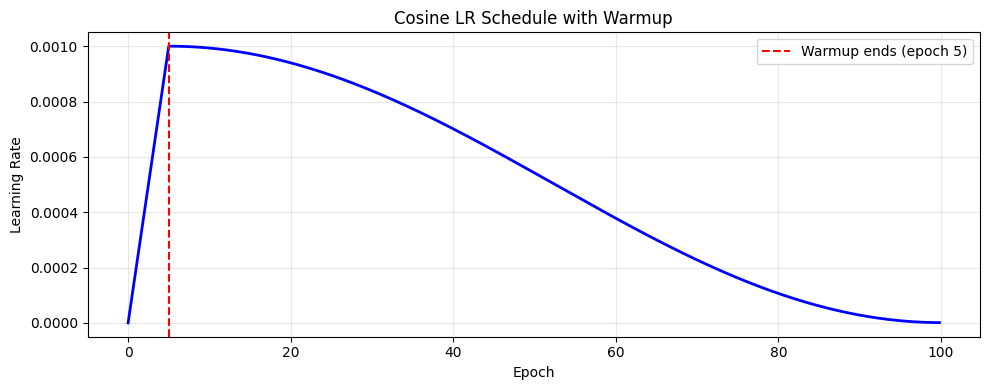

Model compiled with Adam optimizer and cosine LR schedule


In [ ]:
def masked_sparse_crossentropy(y_true, y_pred):
    mask   = tf.cast(tf.not_equal(y_true, -1), tf.float32)
    y_true = tf.maximum(y_true, 0)
    loss   = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    return tf.reduce_sum(loss * mask) / (tf.reduce_sum(mask) + 1e-8)

EPOCHS        = 100
BATCH_SIZE    = 32
INITIAL_LR    = 1e-3
MIN_LR        = 1e-6
WARMUP_EPOCHS = 5

steps_per_epoch = len(train_generator)
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = steps_per_epoch * WARMUP_EPOCHS

print(f"  Epochs: {EPOCHS}")
print(f"  Steps per epoch: {steps_per_epoch}")
print(f"  Total steps: {total_steps:,}")
print(f"  Warmup steps: {warmup_steps} ({WARMUP_EPOCHS} epochs)")

lr_schedule = CosineDecayWithWarmup(
    initial_learning_rate=INITIAL_LR,
    decay_steps=total_steps,
    warmup_steps=warmup_steps,
    min_learning_rate=MIN_LR
)

# visualize LR schedule
steps_range = np.arange(0, total_steps, 100)
lrs = [float(lr_schedule(s)) for s in steps_range]
plt.figure(figsize=(10, 4))
plt.plot(steps_range / steps_per_epoch, lrs, 'b-', linewidth=2)
plt.axvline(x=WARMUP_EPOCHS, color='r', linestyle='--',
            label=f'Warmup ends (epoch {WARMUP_EPOCHS})')
plt.xlabel('Epoch')
plt.ylabel('Learning Rate')
plt.title('Cosine LR Schedule with Warmup')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_schedule),
    loss={
        'single_command': masked_sparse_crossentropy,
        'command_1':      masked_sparse_crossentropy,
        'command_2':      masked_sparse_crossentropy
    },
    loss_weights={'single_command': 1.0, 'command_1': 1.0, 'command_2': 1.0},
    metrics={
        'single_command': 'accuracy',
        'command_1':      'accuracy',
        'command_2':      'accuracy'
    }
)
print("Model compiled with Adam optimizer and cosine LR schedule")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = f'/content/drive/MyDrive/{MODEL_NAME}'
os.makedirs(DRIVE_DIR, exist_ok=True)

callback_list = [
    callbacks.EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ModelCheckpoint(
        f'{DRIVE_DIR}/{MODEL_NAME}.keras',
        monitor='val_loss', save_best_only=True, verbose=1
    ),
    callbacks.CSVLogger('training_log.csv', append=False)
]

print("Callbacks configured — best model saves directly to Drive")
print(f"  Drive directory: {DRIVE_DIR}")

Mounted at /content/drive
Callbacks configured — best model saves directly to Drive
  Drive directory: /content/drive/MyDrive/resnet_sequencing


# Model Performace Analysis

In [ ]:
print(f"Model: ResNet-18 with SE attention")
print(f"Augmentation: SpecAugment + noise mixing")
print(f"LR Schedule: Cosine decay with {WARMUP_EPOCHS}-epoch warmup")
print("=" * 60)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callback_list,
    verbose=2
)

print("Finished training")

Model: ResNet-18 with SE attention
Augmentation: SpecAugment + noise mixing
LR Schedule: Cosine decay with 5-epoch warmup
Epoch 1/100

Epoch 1: val_loss improved from None to 8.14783, saving model to /content/drive/MyDrive/resnet_sequencing/resnet_sequencing.keras

Epoch 1: finished saving model to /content/drive/MyDrive/resnet_sequencing/resnet_sequencing.keras
500/500 - 157s - 315ms/step - command_1_accuracy: 0.0503 - command_1_loss: 3.0385 - command_2_accuracy: 0.0526 - command_2_loss: 3.0910 - loss: 10.0386 - single_command_accuracy: 0.0603 - single_command_loss: 2.7963 - val_command_1_accuracy: 0.0746 - val_command_1_loss: 2.3588 - val_command_2_accuracy: 0.0706 - val_command_2_loss: 2.4636 - val_loss: 8.1478 - val_single_command_accuracy: 0.0935 - val_single_command_loss: 2.2175
Epoch 2/100

Epoch 2: val_loss did not improve from 8.14783
500/500 - 83s - 167ms/step - command_1_accuracy: 0.0653 - command_1_loss: 2.5195 - command_2_accuracy: 0.0717 - command_2_loss: 2.5132 - loss: 8

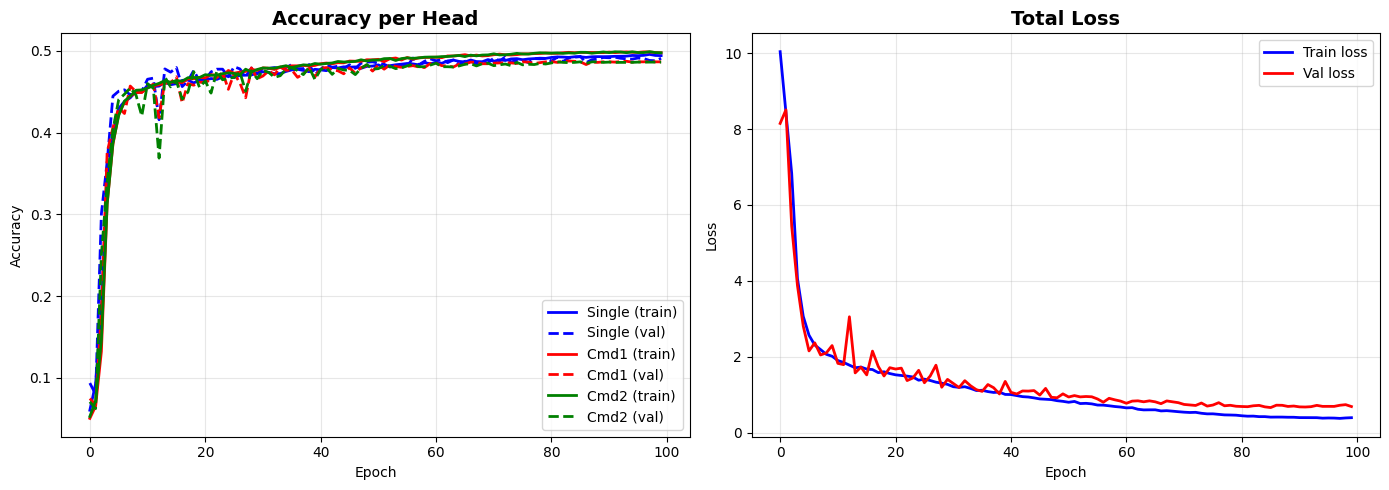

TRAINING SUMMARY
  Total epochs:            100
  Best single cmd val acc: 0.4933 (epoch 86)
  Best cmd1 val acc:       0.4877
  Best cmd2 val acc:       0.4867
  Train/val gap:           +0.0033


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['single_command_accuracy'],     'b-',  label='Single (train)', linewidth=2)
axes[0].plot(history.history['val_single_command_accuracy'], 'b--', label='Single (val)',   linewidth=2)
axes[0].plot(history.history['command_1_accuracy'],          'r-',  label='Cmd1 (train)',   linewidth=2)
axes[0].plot(history.history['val_command_1_accuracy'],      'r--', label='Cmd1 (val)',     linewidth=2)
axes[0].plot(history.history['command_2_accuracy'],          'g-',  label='Cmd2 (train)',   linewidth=2)
axes[0].plot(history.history['val_command_2_accuracy'],      'g--', label='Cmd2 (val)',     linewidth=2)
axes[0].set_title('Accuracy per Head', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     'b-', label='Train loss', linewidth=2)
axes[1].plot(history.history['val_loss'], 'r-', label='Val loss',   linewidth=2)
axes[1].set_title('Total Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_val_acc = max(history.history['val_single_command_accuracy'])
best_epoch   = np.argmax(history.history['val_single_command_accuracy']) + 1
print("TRAINING SUMMARY")
print(f"  Total epochs:            {len(history.history['loss'])}")
print(f"  Best single cmd val acc: {best_val_acc:.4f} (epoch {best_epoch})")
print(f"  Best cmd1 val acc:       {max(history.history['val_command_1_accuracy']):.4f}")
print(f"  Best cmd2 val acc:       {max(history.history['val_command_2_accuracy']):.4f}")
gap = history.history['single_command_accuracy'][-1] - \
      history.history['val_single_command_accuracy'][-1]
print(f"  Train/val gap:           {gap:+.4f}")

In [ ]:
custom_objects = {
    'CosineDecayWithWarmup':      CosineDecayWithWarmup,
    'masked_sparse_crossentropy': masked_sparse_crossentropy
}
best_model = keras.models.load_model(
    f'{DRIVE_DIR}/{MODEL_NAME}.keras',
    custom_objects=custom_objects
)

# ── Single command evaluation ──────────────────────────────────
print("Building single-command test spectrograms...")
X_test_specs = np.array([extract_mel_spectrogram(a) for a in X_raw_test])
X_test_specs = (X_test_specs - X_mean) / X_std
X_test_specs = X_test_specs[..., np.newaxis]

y_pred_all    = best_model.predict(X_test_specs, verbose=0)
y_pred_single = np.argmax(y_pred_all[0], axis=1)
single_acc    = np.mean(y_pred_single == y_test)

# ── Sequential evaluation ──────────────────────────────────────
print("Building sequential test spectrograms...")
X_seq_test_specs = np.array([extract_mel_spectrogram(a) for a in X_seq_test])
X_seq_test_specs = (X_seq_test_specs - X_seq_mean) / X_seq_std
X_seq_test_specs = X_seq_test_specs[..., np.newaxis]

y_pred_seq   = best_model.predict(X_seq_test_specs, verbose=0)
y_pred_cmd1  = np.argmax(y_pred_seq[1], axis=1)
y_pred_cmd2  = np.argmax(y_pred_seq[2], axis=1)
acc_cmd1     = np.mean(y_pred_cmd1 == y_seq_test[:, 0])
acc_cmd2     = np.mean(y_pred_cmd2 == y_seq_test[:, 1])
both_correct = np.mean(
    (y_pred_cmd1 == y_seq_test[:, 0]) &
    (y_pred_cmd2 == y_seq_test[:, 1])
)
test_accuracy = single_acc

print("\n" + "=" * 60)
print("TEST RESULTS")
print("=" * 60)
print(f"  Single command accuracy:     {single_acc:.4f} ({single_acc*100:.2f}%)")
print(f"  Sequential cmd1 accuracy:    {acc_cmd1:.4f} ({acc_cmd1*100:.2f}%)")
print(f"  Sequential cmd2 accuracy:    {acc_cmd2:.4f} ({acc_cmd2*100:.2f}%)")
print(f"  Full sequence accuracy:      {both_correct:.4f} ({both_correct*100:.2f}%)")
print("=" * 60)

print("\nSingle Command - Classification Report:")
print(classification_report(y_test, y_pred_single,
                             target_names=label_encoder.classes_, digits=4))
print("\nSequential Cmd1 - Classification Report:")
print(classification_report(y_seq_test[:, 0], y_pred_cmd1,
                             target_names=label_encoder.classes_, digits=4))
print("\nSequential Cmd2 - Classification Report:")
print(classification_report(y_seq_test[:, 1], y_pred_cmd2,
                             target_names=label_encoder.classes_, digits=4))

Building single-command test spectrograms...
Building sequential test spectrograms...

TEST RESULTS
  Single command accuracy:     0.9141 (91.41%)
  Sequential cmd1 accuracy:    0.9827 (98.27%)
  Sequential cmd2 accuracy:    0.9720 (97.20%)
  Full sequence accuracy:      0.9547 (95.47%)

Single Command - Classification Report:
                    precision    recall  f1-score   support

_background_noise_     0.8235    0.0622    0.1157       225
              down     0.9433    0.9642    0.9537       587
                go     0.9583    0.9485    0.9534       582
              left     0.9961    0.8982    0.9446       570
                no     0.9961    0.8596    0.9228       591
               off     0.9147    0.9537    0.9338       562
                on     0.8652    0.9792    0.9187       577
             right     0.7322    0.9788    0.8377       567
              stop     0.9644    0.9793    0.9718       581
                up     0.8741    0.9211    0.8970       558
          

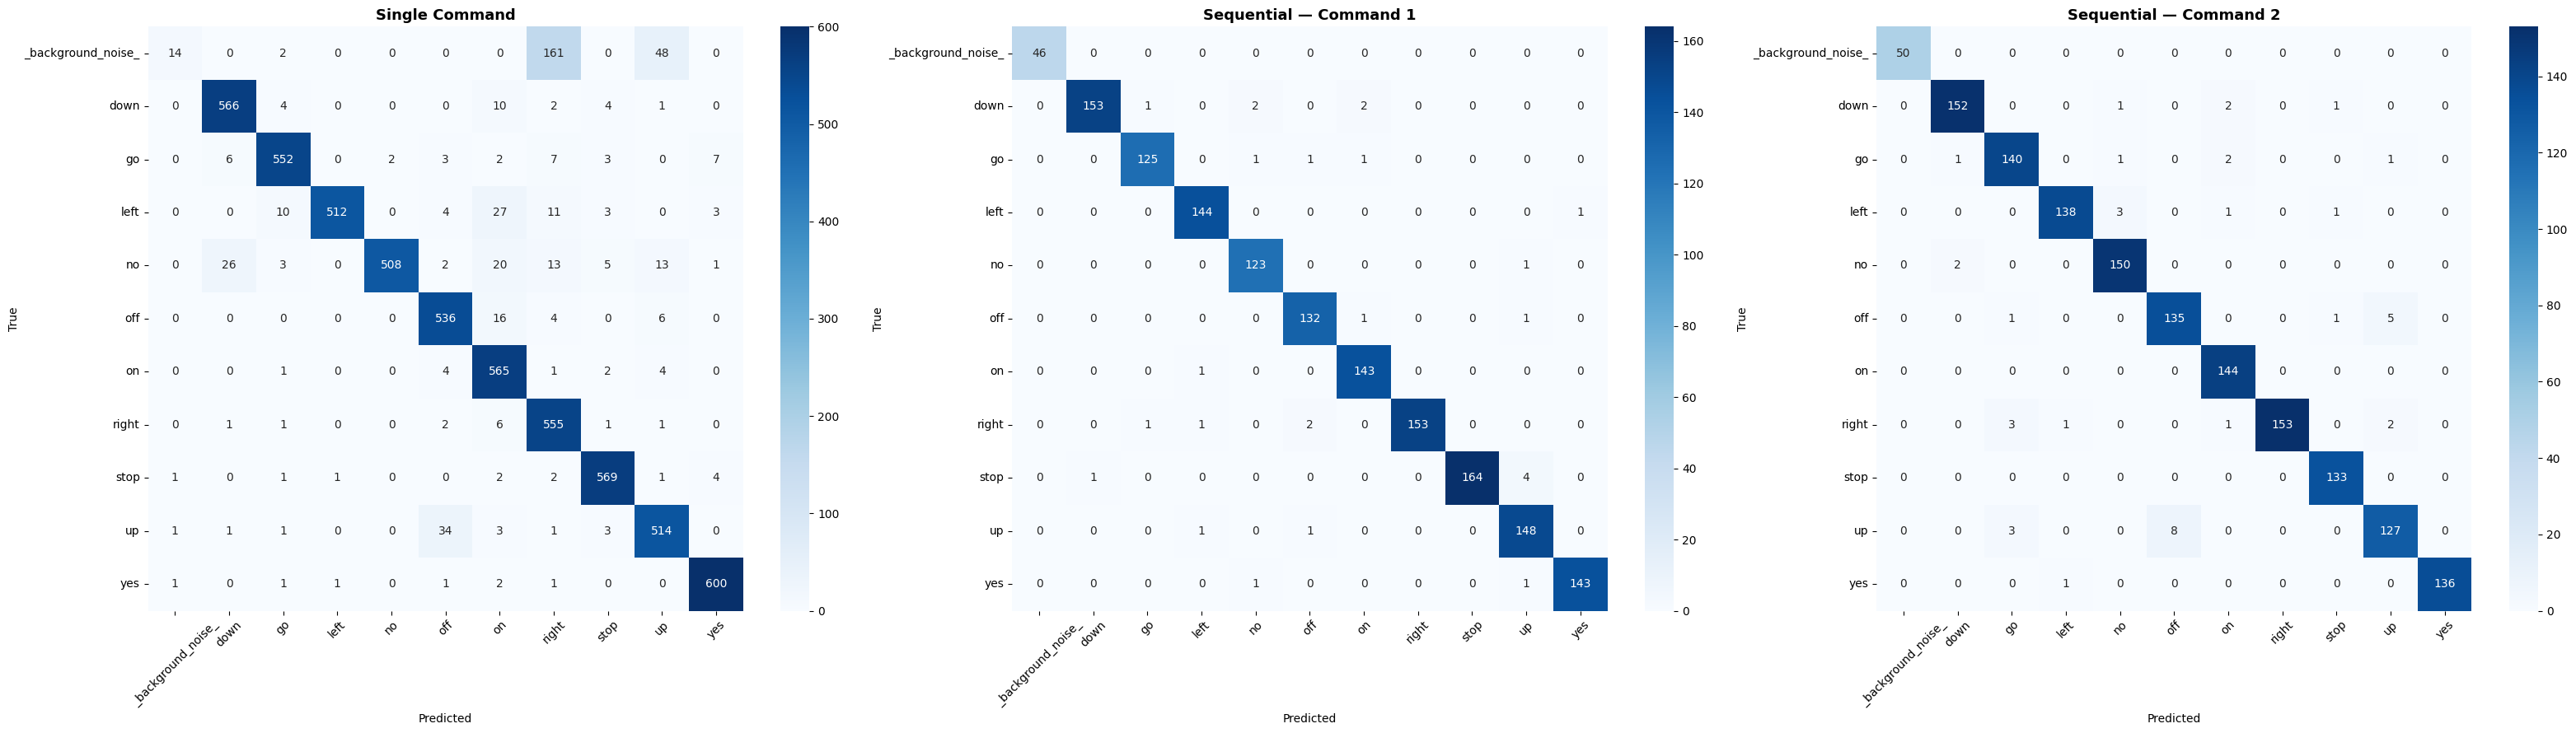

Per-Class Accuracy (Single Command Head):
----------------------------------------
  yes                 : 0.9885 █████████████████████████████
  stop                : 0.9793 █████████████████████████████
  on                  : 0.9792 █████████████████████████████
  right               : 0.9788 █████████████████████████████
  down                : 0.9642 ████████████████████████████
  off                 : 0.9537 ████████████████████████████
  go                  : 0.9485 ████████████████████████████
  up                  : 0.9211 ███████████████████████████
  left                : 0.8982 ██████████████████████████
  no                  : 0.8596 █████████████████████████
  _background_noise_  : 0.0622 █


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(32, 9))

for ax, y_true, y_pred_labels, title in [
    (axes[0], y_test,           y_pred_single, 'Single Command'),
    (axes[1], y_seq_test[:, 0], y_pred_cmd1,   'Sequential — Command 1'),
    (axes[2], y_seq_test[:, 1], y_pred_cmd2,   'Sequential — Command 2'),
]:
    cm = confusion_matrix(y_true, y_pred_labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_, ax=ax)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Per-Class Accuracy (Single Command Head):")
print("-" * 40)
cm_single      = confusion_matrix(y_test, y_pred_single)
class_accuracy = cm_single.diagonal() / cm_single.sum(axis=1)
for name, acc in sorted(zip(label_encoder.classes_, class_accuracy), key=lambda x: -x[1]):
    bar = '█' * int(acc * 30)
    print(f"  {name:20s}: {acc:.4f} {bar}")

In [ ]:
import json, pickle

print("=" * 60)
print("SAVING MODEL AND ARTIFACTS")
print("=" * 60)

model.save(f'{MODEL_NAME}_final.keras')

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

config = {
    'model_name':          MODEL_NAME,
    'commands':            list(label_encoder.classes_),
    'num_classes':         num_classes,
    'sample_rate':         SAMPLE_RATE,
    'audio_length':        AUDIO_LENGTH,
    'n_mels':              N_MELS,
    'n_fft':               N_FFT,
    'hop_length':          HOP_LENGTH,
    'single_mean':         float(X_mean),
    'single_std':          float(X_std),
    'seq_mean':            float(X_seq_mean),
    'seq_std':             float(X_seq_std),
    'noise_augmentation':  True,
    'noise_prob':          NOISE_AUGMENT_PROB,
    'noise_snr_db':        NOISE_SNR_DB,
    'noise_class_samples': len(noise_samples),
    'max_output_len':      MAX_OUTPUT_LEN,
    'single_test_acc':     float(single_acc),
    'seq_cmd1_acc':        float(acc_cmd1),
    'seq_cmd2_acc':        float(acc_cmd2),
    'seq_both_acc':        float(both_correct),
    'best_val_acc':        float(best_val_acc),
    'training_epochs':     len(history.history['loss'])
}

with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)

print(f"✓ Final model saved: {MODEL_NAME}_final.keras")
print("✓ Label encoder saved: label_encoder.pkl")
print("✓ Config saved: model_config.json")
print(json.dumps(config, indent=2))

SAVING MODEL AND ARTIFACTS
✓ Final model saved: resnet_sequencing_final.keras
✓ Label encoder saved: label_encoder.pkl
✓ Config saved: model_config.json
{
  "model_name": "resnet_sequencing",
  "commands": [
    "_background_noise_",
    "down",
    "go",
    "left",
    "no",
    "off",
    "on",
    "right",
    "stop",
    "up",
    "yes"
  ],
  "num_classes": 11,
  "sample_rate": 16000,
  "audio_length": 16000,
  "n_mels": 128,
  "n_fft": 2048,
  "hop_length": 160,
  "single_mean": -56.730995178222656,
  "single_std": 20.285085678100586,
  "seq_mean": -61.67680706851633,
  "seq_std": 19.54796869734301,
  "noise_augmentation": true,
  "noise_prob": 0.4,
  "noise_snr_db": 10,
  "noise_class_samples": 1500,
  "max_output_len": 2,
  "single_test_acc": 0.9141002164141835,
  "seq_cmd1_acc": 0.9826666666666667,
  "seq_cmd2_acc": 0.972,
  "seq_both_acc": 0.9546666666666667,
  "best_val_acc": 0.49334222078323364,
  "training_epochs": 100
}


In [ ]:
files_to_copy = [
    f'{MODEL_NAME}_final.keras',
    'label_encoder.pkl',
    'model_config.json',
    'training_log.csv'
]

print(f"Copying files to: {DRIVE_DIR}")
for f in files_to_copy:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(DRIVE_DIR, f))
        print(f"  ✓ {f}")
    else:
        print(f"  ⚠️  {f} not found")

print(f"\n✓ Drive folder contains:")
print(f"  • {MODEL_NAME}.keras          ← best checkpoint (saved during training)")
print(f"  • {MODEL_NAME}_final.keras    ← final epoch")
print(f"  • label_encoder.pkl")
print(f"  • model_config.json")
print(f"  • training_log.csv")

Copying files to: /content/drive/MyDrive/resnet_sequencing
  ✓ resnet_sequencing_final.keras
  ✓ label_encoder.pkl
  ✓ model_config.json
  ✓ training_log.csv

✓ Drive folder contains:
  • resnet_sequencing.keras          ← best checkpoint (saved during training)
  • resnet_sequencing_final.keras    ← final epoch
  • label_encoder.pkl
  • model_config.json
  • training_log.csv


In [ ]:
utils_code = '''
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import register_keras_serializable

@register_keras_serializable(package="CustomSchedules")
class CosineDecayWithWarmup(keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_learning_rate=1e-3, decay_steps=10000,
                 warmup_steps=1000, min_learning_rate=1e-6):
        super().__init__()
        self.initial_learning_rate = initial_learning_rate
        self.decay_steps           = decay_steps
        self.warmup_steps          = warmup_steps
        self.min_learning_rate     = min_learning_rate

    def __call__(self, step):
        step     = tf.cast(step, tf.float32)
        warmup_f = tf.cast(self.warmup_steps, tf.float32)
        decay_f  = tf.cast(self.decay_steps,  tf.float32)
        warmup_lr   = self.initial_learning_rate * (step / tf.maximum(warmup_f, 1.0))
        decay_step  = step - warmup_f
        total_decay = tf.maximum(decay_f - warmup_f, 1.0)
        cosine      = 0.5 * (1.0 + tf.cos(np.pi * decay_step / total_decay))
        decayed_lr  = self.min_learning_rate + \
                      (self.initial_learning_rate - self.min_learning_rate) * cosine
        return tf.where(step < warmup_f, warmup_lr, decayed_lr)

    def get_config(self):
        return {
            'initial_learning_rate': float(self.initial_learning_rate),
            'decay_steps':           int(self.decay_steps),
            'warmup_steps':          int(self.warmup_steps),
            'min_learning_rate':     float(self.min_learning_rate)
        }

    @classmethod
    def from_config(cls, config):
        return cls(**config)


def masked_sparse_crossentropy(y_true, y_pred):
    import tensorflow as tf
    from tensorflow import keras
    mask   = tf.cast(tf.not_equal(y_true, -1), tf.float32)
    y_true = tf.maximum(y_true, 0)
    loss   = keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    return tf.reduce_sum(loss * mask) / (tf.reduce_sum(mask) + 1e-8)
'''

with open(os.path.join(DRIVE_DIR, 'utils.py'), 'w') as f:
    f.write(utils_code)
print("✓ utils.py saved to Drive")
print(f"\nTo load the model anywhere:")
print(f"  from utils import CosineDecayWithWarmup, masked_sparse_crossentropy")
print(f"  from tensorflow import keras")
print(f"  model = keras.models.load_model('{MODEL_NAME}.keras',")
print(f"    custom_objects={{")
print(f"      'CosineDecayWithWarmup': CosineDecayWithWarmup,")
print(f"      'masked_sparse_crossentropy': masked_sparse_crossentropy")
print(f"    }})")

✓ utils.py saved to Drive

To load the model anywhere:
  from utils import CosineDecayWithWarmup, masked_sparse_crossentropy
  from tensorflow import keras
  model = keras.models.load_model('resnet_sequencing.keras',
    custom_objects={
      'CosineDecayWithWarmup': CosineDecayWithWarmup,
      'masked_sparse_crossentropy': masked_sparse_crossentropy
    })
